# Анализ отзывов «Суши Студио» и конкурентов

**Цель:** определить, по каким показателям целевая компания опережает прямых конкурентов или уступает им, проверить статистические гипотезы и подготовить рекомендации для бизнеса.

**Период анализа:** с 1 января 2020 года по 2 августа 2023 года. Начало периода выбрано так, чтобы все компании конкурентной группы были представлены в данных.

**Целевая компания:** «Суши Студио».

**Конкуренты:** «Суши Точка», Sushi Holl, «Сушишоп», «Суши мастер», «Мистер лосось» и Arigato.

## 1. Подготовка среды

Импортируем основной модуль проекта. В нём находятся документированные функции очистки, лемматизации, построения модели, проверки гипотез и экспорта результатов. Фиксированный `random_state=42` обеспечивает воспроизводимость разбиения выборки.

In [1]:
from pathlib import Path
import json
import sys
import warnings

import pandas as pd
from IPython.display import Image, display

# Ноутбук запускается из корня проекта; добавляем папку src в путь импорта.
PROJECT_DIR = Path.cwd()
sys.path.insert(0, str(PROJECT_DIR / "src"))

import analysis_pipeline as pipeline

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

pipeline.ensure_directories()
print(f"Корень проекта: {PROJECT_DIR}")
print(f"Исходный файл найден: {pipeline.SOURCE_CSV.exists()}")

Корень проекта: C:\Users\Rostyan\Desktop\Практика_Ева\Eva\Проект_анализа_отзывов
Исходный файл найден: True


## 2. Загрузка и аудит качества данных

Удаляем только полные дубли строк. Названия, адреса и тексты очищаем от неразрывных и невидимых пробелов. Даты и оценки преобразуем в числовые типы, нераспознанные значения считаем пропусками.

In [2]:
# Загружаем полную выгрузку и получаем протокол очистки.
clean, quality = pipeline.load_and_clean()

quality_table = (
    pd.Series(quality, name="Количество")
    .rename_axis("Показатель")
    .to_frame()
)
display(quality_table)
display(clean.head(3))

,Количество
Показатель,
initial_rows,94069
exact_duplicates_removed,2350
rows_after_deduplication,91719
missing_address,41
missing_or_invalid_date,66
missing_or_invalid_score,61
missing_comment,3275


,Source,Brand,Specialization,Description,Adress,Date,Score,Comment,date,score,comment_clean
0,DGIS,Sushi Holl,Ресторан доставки,Дополнительное описание отсутсвует,"Пискунова, 146, Иркутск",02.08.2023,5.0000,Вкусно очень,2023-08-02,5.0000,вкусно очень
1,DGIS,Sushi Holl,Ресторан доставки,Дополнительное описание отсутсвует,"Пискунова, 146, Иркутск",30.07.2023,4.0000,Заказывали роллы все свежее вкусное только тем...,2023-07-30,4.0000,заказывали роллы все свежее вкусное только тем...
2,DGIS,Sushi Holl,Ресторан доставки,Дополнительное описание отсутсвует,"Пискунова, 146, Иркутск",28.07.2023,5.0000,цена качество и скорость топ советую,2023-07-28,5.0000,цена качество и скорость топ советую


## 3. Формирование сопоставимой выборки

Оставляем семь компаний, общий период, валидные оценки и непустые тексты. Отзывы без текста подходят для подсчёта общего рейтинга, но не для тематического анализа, поэтому в основную аналитическую выборку не включаются.

In [3]:
# Отбираем целевую компанию и прямых конкурентов.
sample = pipeline.select_analysis_sample(clean)

sample_profile = (
    sample.groupby("Brand")
    .agg(
        Отзывов=("review_id", "size"),
        Адресов=("Adress", "nunique"),
        Начало=("date", "min"),
        Конец=("date", "max"),
        Средняя_оценка=("score", "mean"),
    )
    .sort_values("Отзывов", ascending=False)
)
display(sample_profile)
print(f"Размер сопоставимой выборки: {len(sample):,} отзывов")

,Отзывов,Адресов,Начало,Конец,Средняя_оценка
Brand,,,,,
Суши Студио,4054,3,2020-01-02,2023-08-02,4.6300
Суши Точка,968,3,2020-01-11,2023-08-02,4.6663
Суши мастер,334,1,2020-02-04,2023-08-02,2.3144
Сушишоп,288,1,2020-01-15,2023-08-02,3.7743
Sushi Holl,272,1,2020-01-13,2023-08-02,4.1544
Мистер лосось,237,1,2020-01-28,2023-08-02,4.6540
Arigato,211,1,2020-01-01,2023-08-02,4.0237


Размер сопоставимой выборки: 6,364 отзывов


## 4. Предобработка текста и лемматизация

Текст приводится к нижнему регистру, очищается от ссылок и лишних символов. Затем слова приводятся к нормальной форме с помощью `pymorphy3`. Повторяющиеся слова разбираются один раз благодаря кэшированию.

In [4]:
# Лемматизация нужна для устойчивого поиска тем: «доставили», «доставка»
# и «доставкой» должны рассматриваться как связанные формы.
sample = pipeline.add_lemmas(sample)
sample = pipeline.categorize_reviews(sample)

display(
    sample[["Comment", "lemma_text", "primary_category"]]
    .sample(5, random_state=42)
)

,Comment,lemma_text,primary_category
6244,Отвратительное место на Седова. Администратор ...,отвратительный место седов администратор мадам...,сервис_и_персонал
2949,Самые лучшие и вкусные суши быстрая доставка б...,самый хороший вкусный сушить быстрый доставка ...,вкус
393,Атмосфера приятная от обслуживания я не в вост...,атмосфера приятный обслуживание восторг кухня ...,вкус
4852,Давно знакома с данным заведением. Официанты р...,давно знакомый данные заведение официант работ...,сервис_и_персонал
2154,Буквально вчера купили с мужем три вида роллов...,буквально вчера купить муж три вид ролл доволь...,цена_и_ценность


## 5. Первичный анализ компаний

Для каждой компании рассчитываем объём выборки, среднюю и медианную оценку, доли негативных и позитивных отзывов. Для доли негатива используется 95%-й интервал Уилсона.

In [5]:
company_summary = pipeline.build_company_summary(sample)

summary_view = company_summary.copy()
for column in ["negative_share", "negative_ci_low", "negative_ci_high", "positive_share"]:
    summary_view[column] = summary_view[column].map(lambda value: f"{value:.1%}")
summary_view["mean_score"] = summary_view["mean_score"].round(3)

display(summary_view)

,brand,reviews,addresses,mean_score,median_score,negative_share,negative_ci_low,negative_ci_high,positive_share,start_date,end_date
0,Суши Точка,968,3,4.6660,5.0000,7.6%,6.1%,9.5%,91.3%,2020-01-11,2023-08-02
1,Мистер лосось,237,1,4.6540,5.0000,8.4%,5.5%,12.7%,90.7%,2020-01-28,2023-08-02
2,Суши Студио,4054,3,4.6300,5.0000,8.1%,7.3%,9.0%,90.0%,2020-01-02,2023-08-02
3,Sushi Holl,272,1,4.1540,5.0000,17.3%,13.3%,22.2%,76.5%,2020-01-13,2023-08-02
4,Arigato,211,1,4.0240,5.0000,22.7%,17.6%,28.9%,73.0%,2020-01-01,2023-08-02
5,Сушишоп,288,1,3.7740,5.0000,28.5%,23.6%,33.9%,65.6%,2020-01-15,2023-08-02
6,Суши мастер,334,1,2.3140,1.0000,66.5%,61.2%,71.3%,30.8%,2020-02-04,2023-08-02


## 6. Модель эмоциональной тональности

В качестве приближённой разметки используются оценки: 1–2 — негатив, 4–5 — позитив. Отзывы с оценкой 3 не участвуют в обучении бинарной модели. Признаки создаются методом TF-IDF, классификатор — логистическая регрессия с балансировкой классов.

Такая модель прозрачна и воспроизводима, но не заменяет ручную экспертную разметку: оценка и смысл текста иногда расходятся.

,Значение
Обучающих строк,4979.0000
Тестовых строк,1245.0000
Accuracy,0.9671
F1 позитивного класса,0.9809
ROC-AUC,0.9887


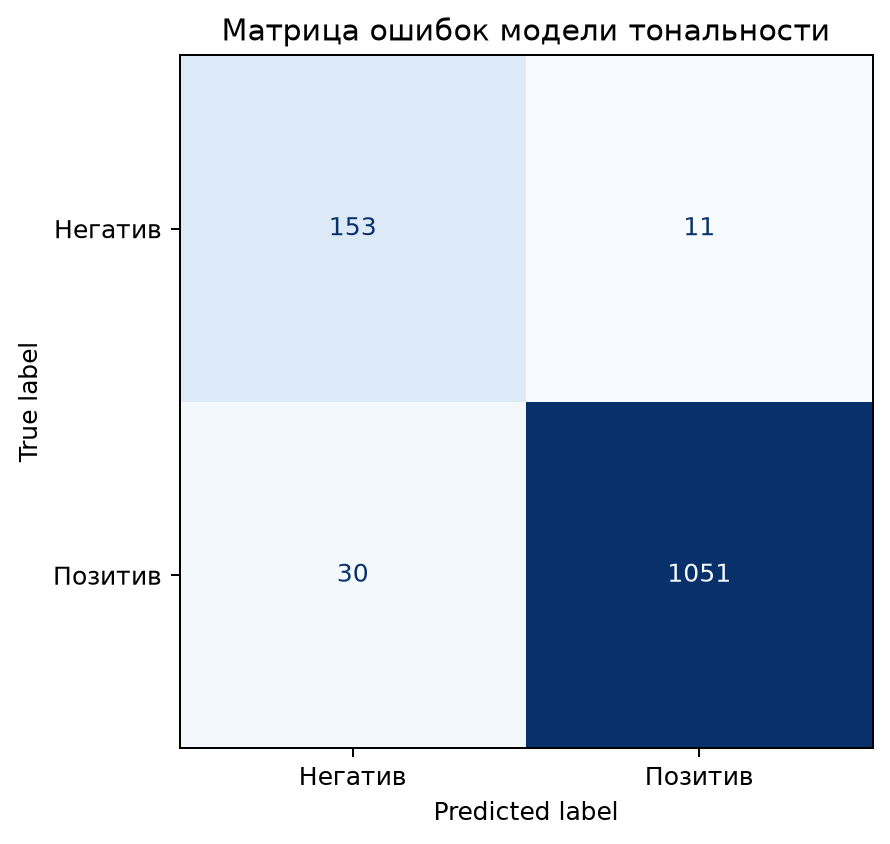

In [6]:
# Обучаем модель и добавляем к каждой строке вероятность позитивной тональности.
sample, model_metrics, sentiment_model = pipeline.train_sentiment_model(sample)

metrics_view = pd.Series(
    {
        "Обучающих строк": model_metrics["train_rows"],
        "Тестовых строк": model_metrics["test_rows"],
        "Accuracy": model_metrics["accuracy"],
        "F1 позитивного класса": model_metrics["f1_positive"],
        "ROC-AUC": model_metrics["roc_auc"],
    }
)
display(metrics_view.to_frame("Значение"))
display(Image(filename=str(pipeline.FIGURE_DIR / "07_model_confusion_matrix.png"), width=520))

## 7. Категоризация жалоб

Категории определяются по документированному словарю лемм. Один отзыв может содержать несколько проблем. Сравнение проводится только среди негативных отзывов, чтобы позитивное упоминание сервиса или доставки не считалось жалобой.

In [7]:
category_summary = pipeline.build_category_summary(sample)
category_view = category_summary.pivot(index="category", columns="group", values="share")
display(category_view.map(lambda value: f"{value:.1%}"))

top_words = pipeline.top_lemmas(sample, limit=20)
display(top_words.pivot(index="lemma", columns="group", values="count").fillna(0).head(20))

group,Конкуренты,Суши Студио
category,,
вкус,40.4%,28.6%
интерьер_и_атмосфера,1.4%,17.3%
качество_еды,31.6%,28.6%
комплектность_заказа,12.0%,10.3%
сервис_и_персонал,22.9%,47.7%
скорость_и_доставка,45.0%,52.0%
упаковка,5.5%,4.0%
цена_и_ценность,9.5%,8.8%
чистота,1.8%,5.5%


group,Конкуренты,Суши Студио
lemma,,
большой,112.0000,87.0000
время,105.0000,105.0000
всё,184.0000,154.0000
доставка,208.0000,134.0000
ещё,98.0000,81.0000
ждать,98.0000,0.0000
заведение,0.0000,80.0000
заказ,367.0000,282.0000
заказать,171.0000,83.0000


## 8. Проверка гипотез

- **H1:** распределение оценок «Суши Студио» отличается от каждого конкурента.
- **H2:** доля негативных отзывов отличается от объединённой группы конкурентов.
- **H3:** структура жалоб отличается от конкурентов.
- **H4:** филиалы «Суши Студио» имеют одинаковое распределение оценок.
- **H5:** месячная средняя оценка компании имеет монотонный тренд.

Для H1 применяется критерий Манна–Уитни и поправка Холма. Для долей — двусторонний z-тест с поправкой Холма. Для филиалов — критерий Краскела–Уоллиса, для тренда — корреляция Спирмена.

In [8]:
hypotheses, extra_tests = pipeline.test_hypotheses(sample)

hypothesis_view = hypotheses.copy()
hypothesis_view["Вывод"] = hypothesis_view["significant_005"].map(
    {True: "Различие статистически значимо", False: "Значимое различие не обнаружено"}
)
display(
    hypothesis_view[
        ["hypothesis", "comparison", "metric", "target_value", "comparison_value", "effect", "p_adjusted", "Вывод"]
    ]
)
display(pd.Series(extra_tests, name="Значение").to_frame())

,hypothesis,comparison,metric,target_value,comparison_value,effect,p_adjusted,Вывод
0,H1,Суши Студио — Суши Точка,распределение оценок,4.6300,4.6663,-0.0167,0.3096,Значимое различие не обнаружено
1,H1,Суши Студио — Sushi Holl,распределение оценок,4.6300,4.1544,0.1889,0.0000,Различие статистически значимо
2,H1,Суши Студио — Сушишоп,распределение оценок,4.6300,3.7743,0.2530,0.0000,Различие статистически значимо
3,H1,Суши Студио — Суши мастер,распределение оценок,4.6300,2.3144,0.6207,0.0000,Различие статистически значимо
4,H1,Суши Студио — Мистер лосось,распределение оценок,4.6300,4.6540,-0.0248,0.3096,Значимое различие не обнаружено
5,H1,Суши Студио — Arigato,распределение оценок,4.6300,4.0237,0.1667,0.0000,Различие статистически значимо
6,H2,Суши Студио — конкуренты вместе,доля негативных отзывов,0.0812,0.2134,-0.1323,0.0000,Различие статистически значимо
7,H3,Суши Студио — конкуренты вместе,жалоба: качество_еды,0.2857,0.3164,-0.0307,1.0000,Значимое различие не обнаружено
8,H3,Суши Студио — конкуренты вместе,жалоба: вкус,0.2857,0.4037,-0.1179,0.0038,Различие статистически значимо
9,H3,Суши Студио — конкуренты вместе,жалоба: скорость_и_доставка,0.5198,0.4503,0.0695,0.2540,Значимое различие не обнаружено


,Значение
complaint_profile_chi2,102.4720
complaint_profile_p_value,0.0000
complaint_profile_cramers_v,0.1441


## 9. Визуализация результатов

Строим единый набор графиков для отчёта: распределение оценок, средние значения, доля негатива, динамика, категории жалоб и филиалы целевой компании.

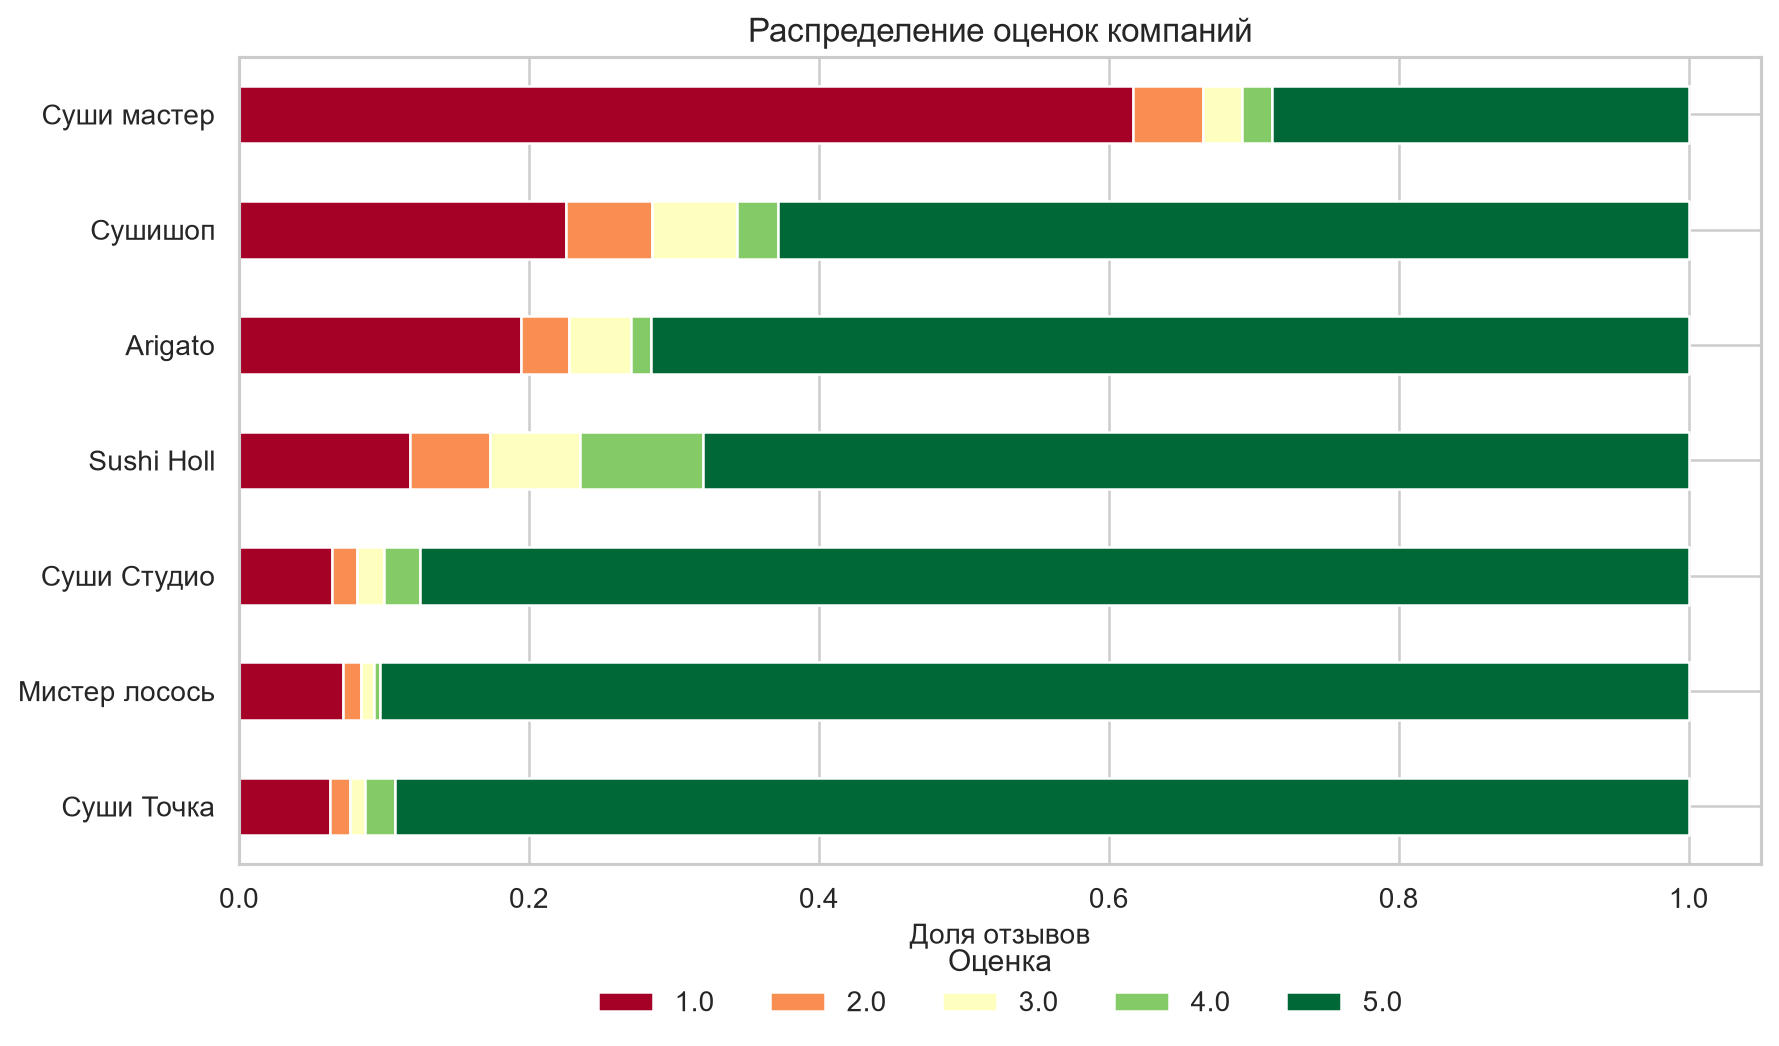

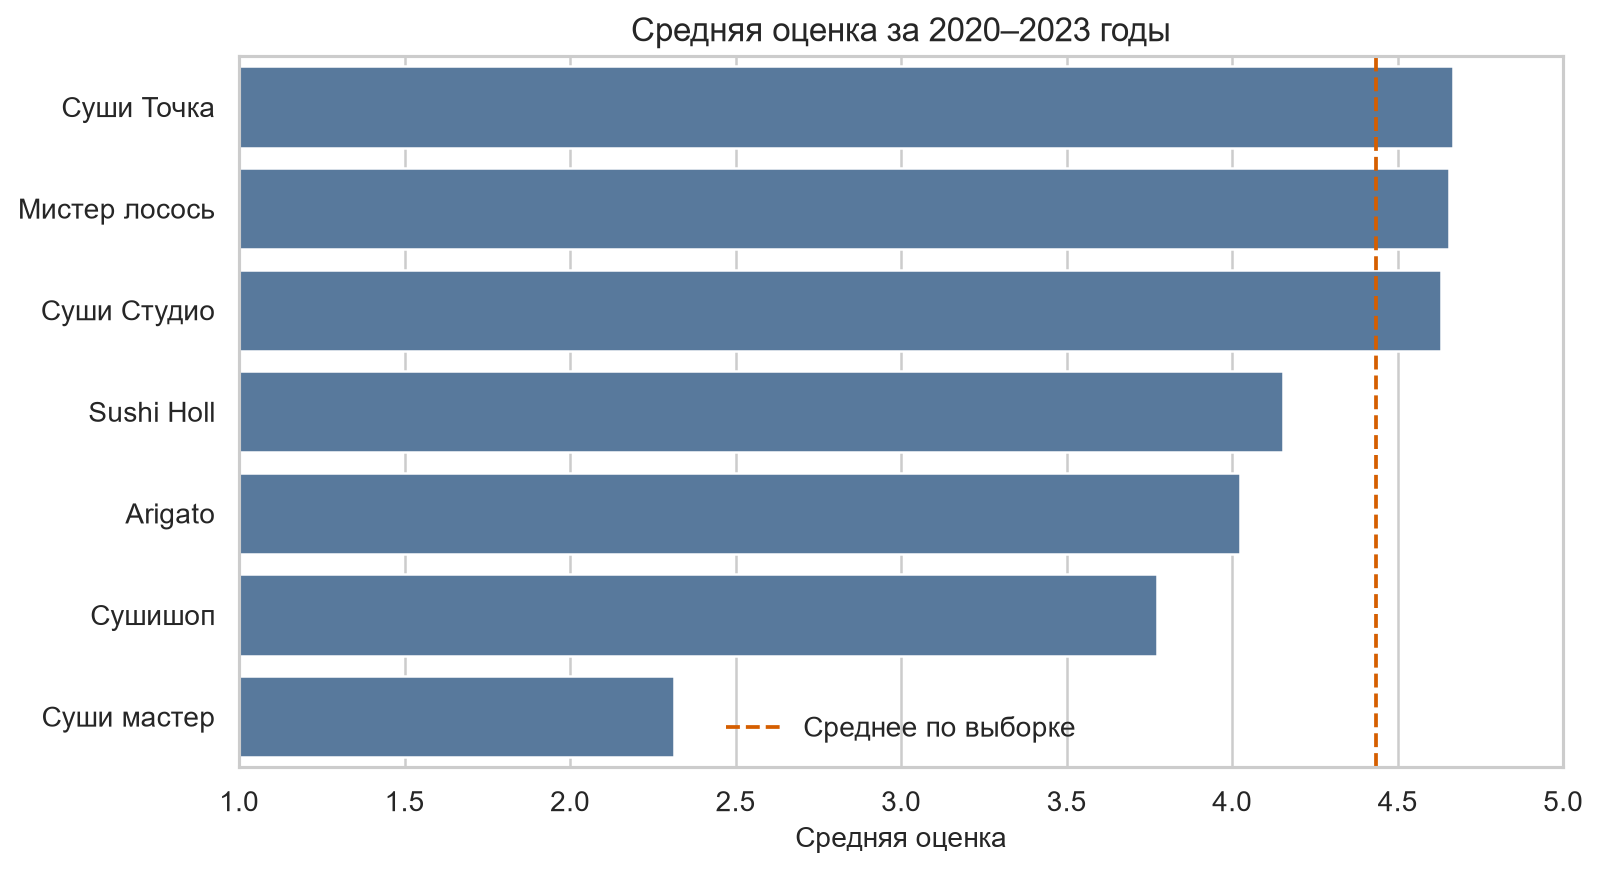

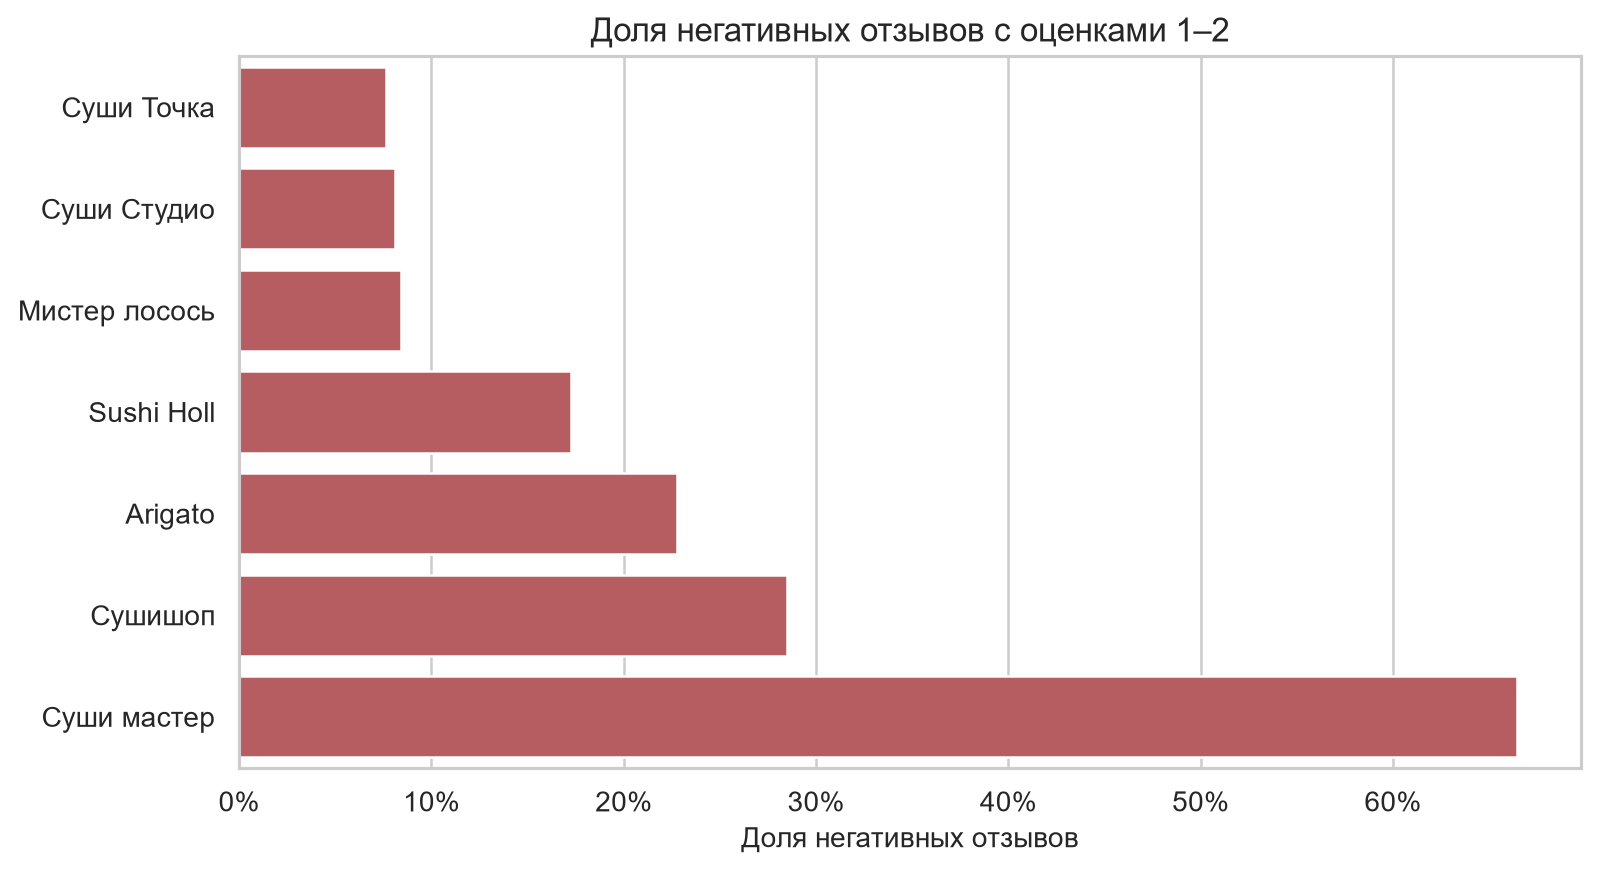

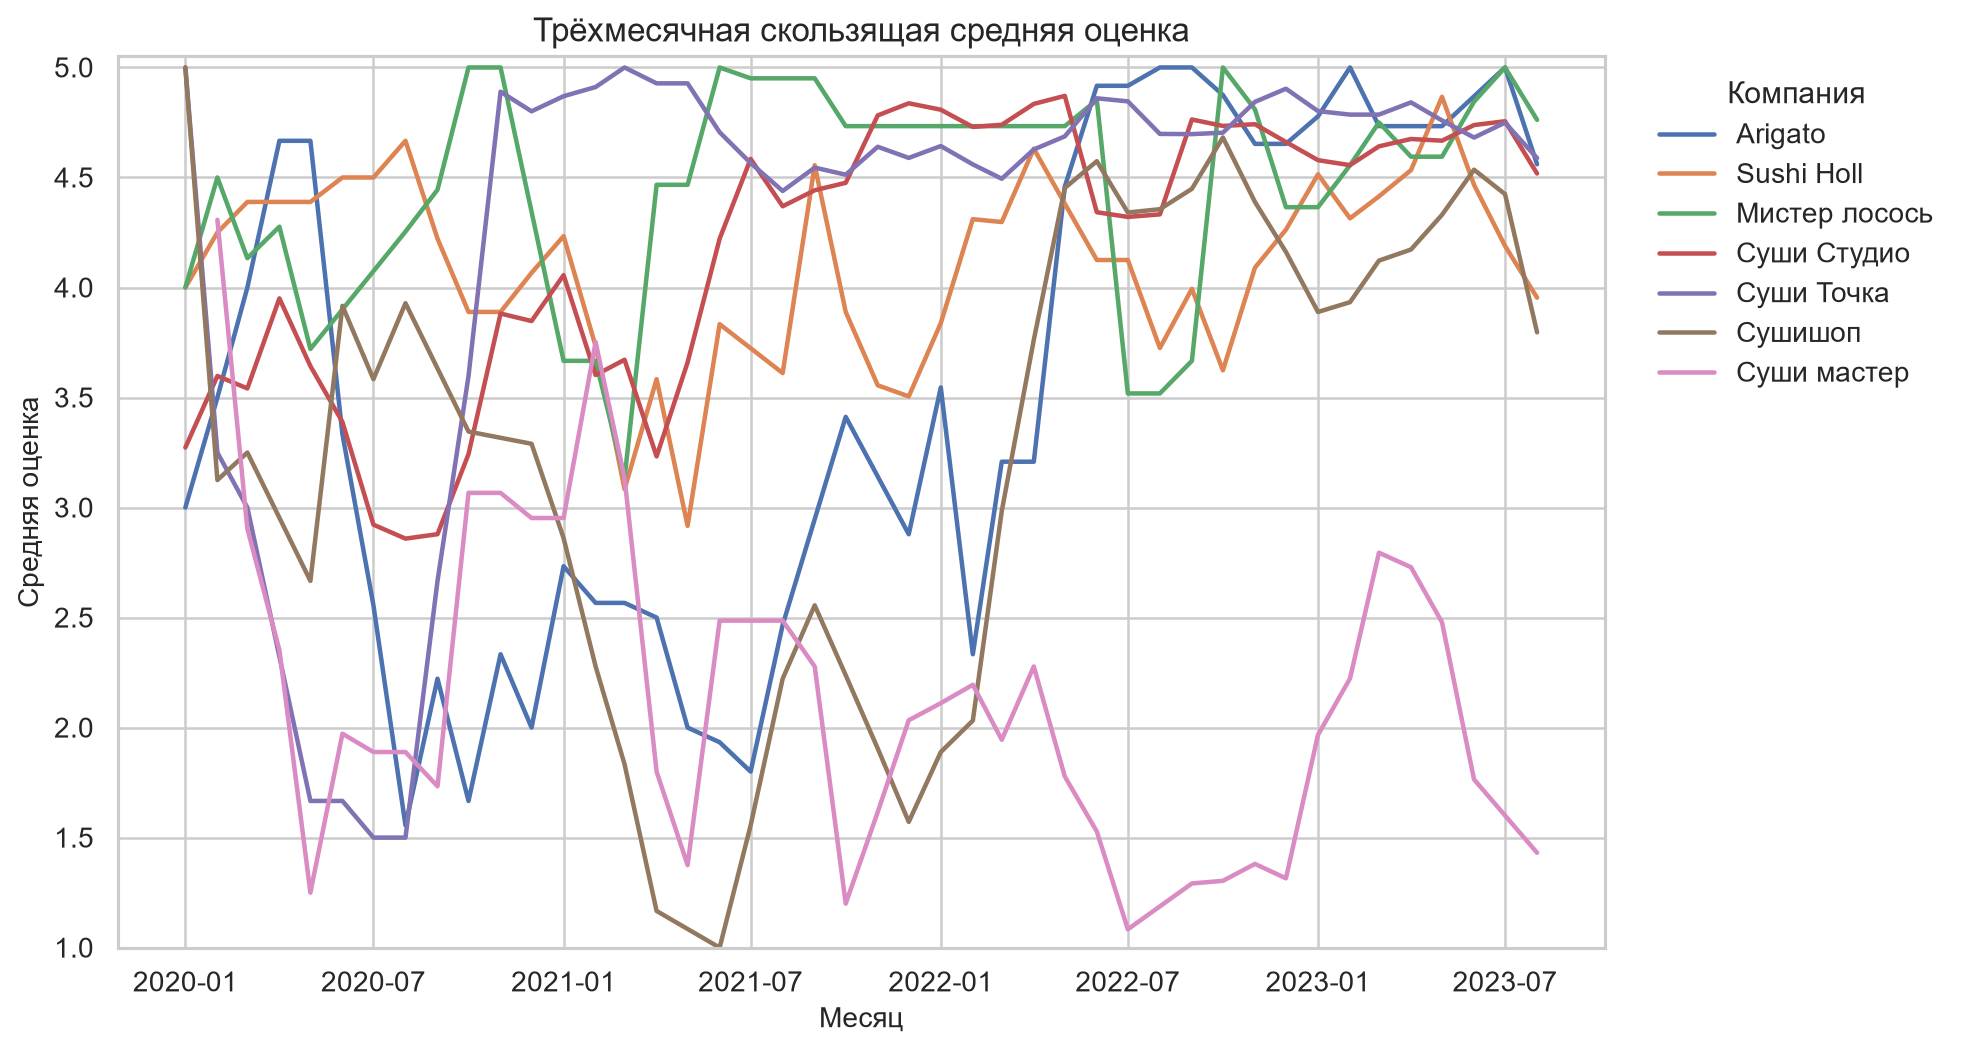

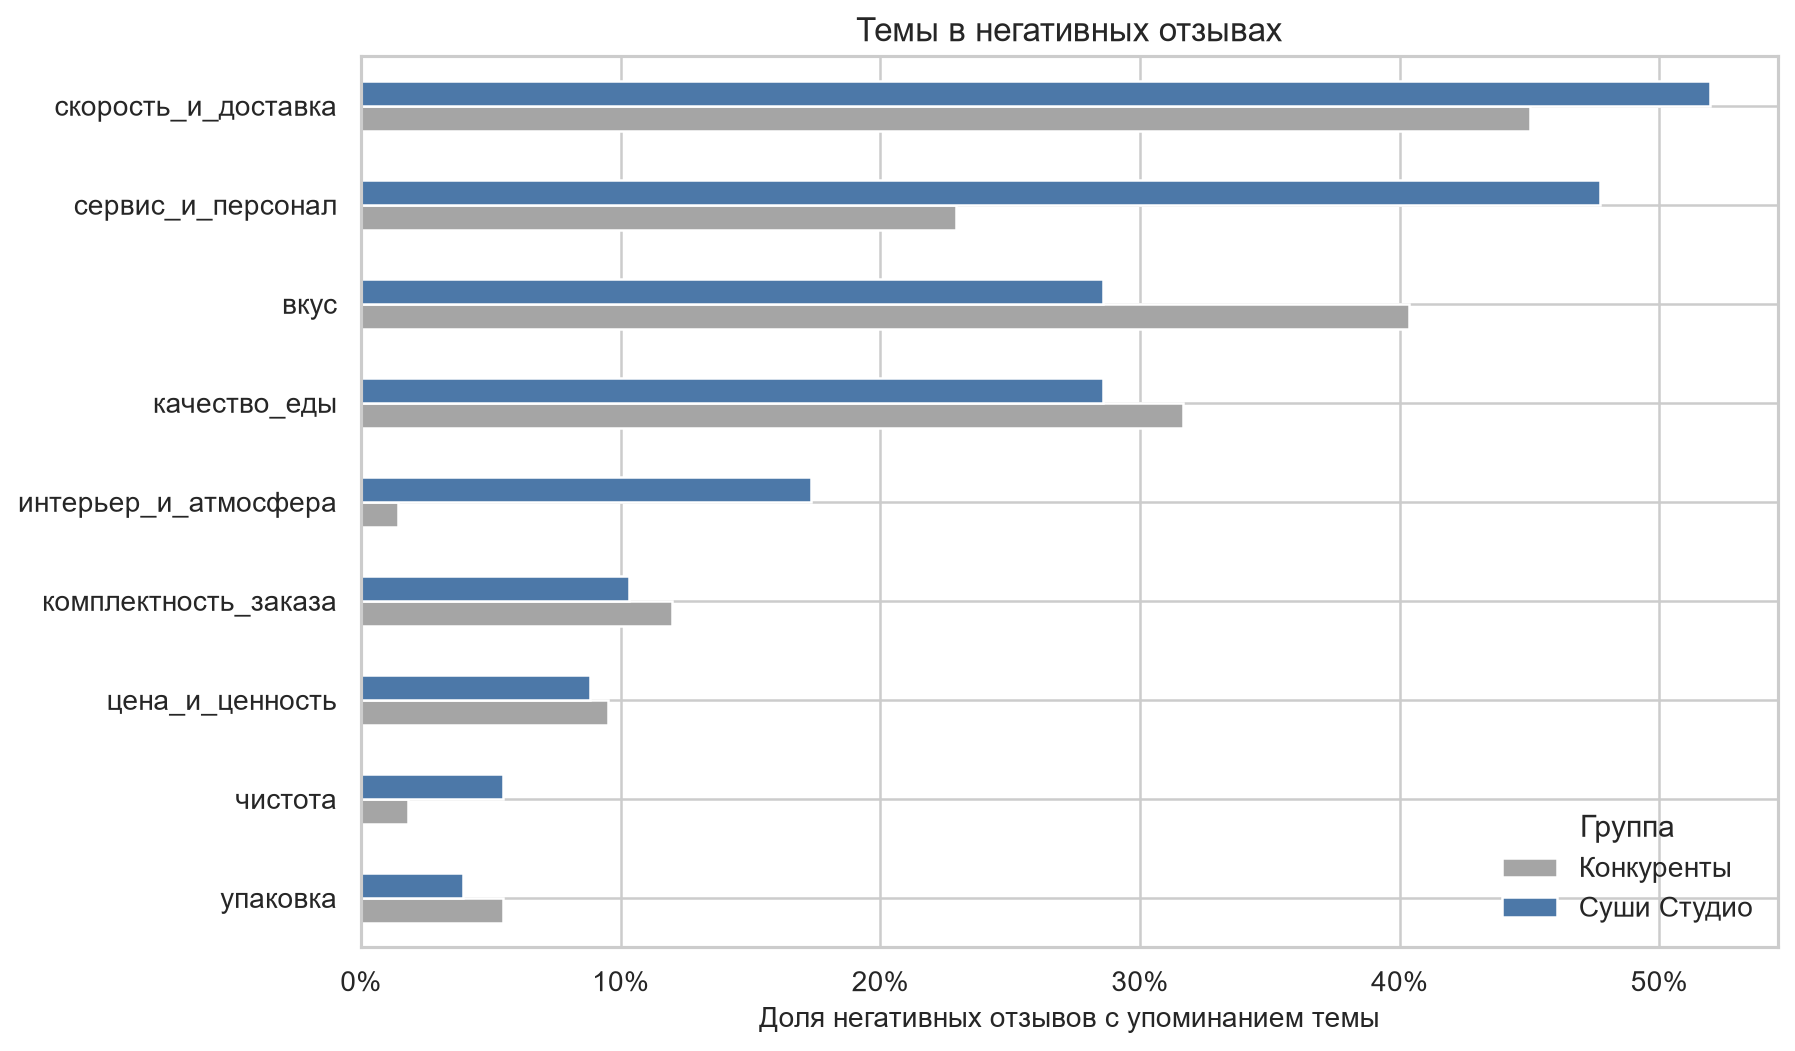

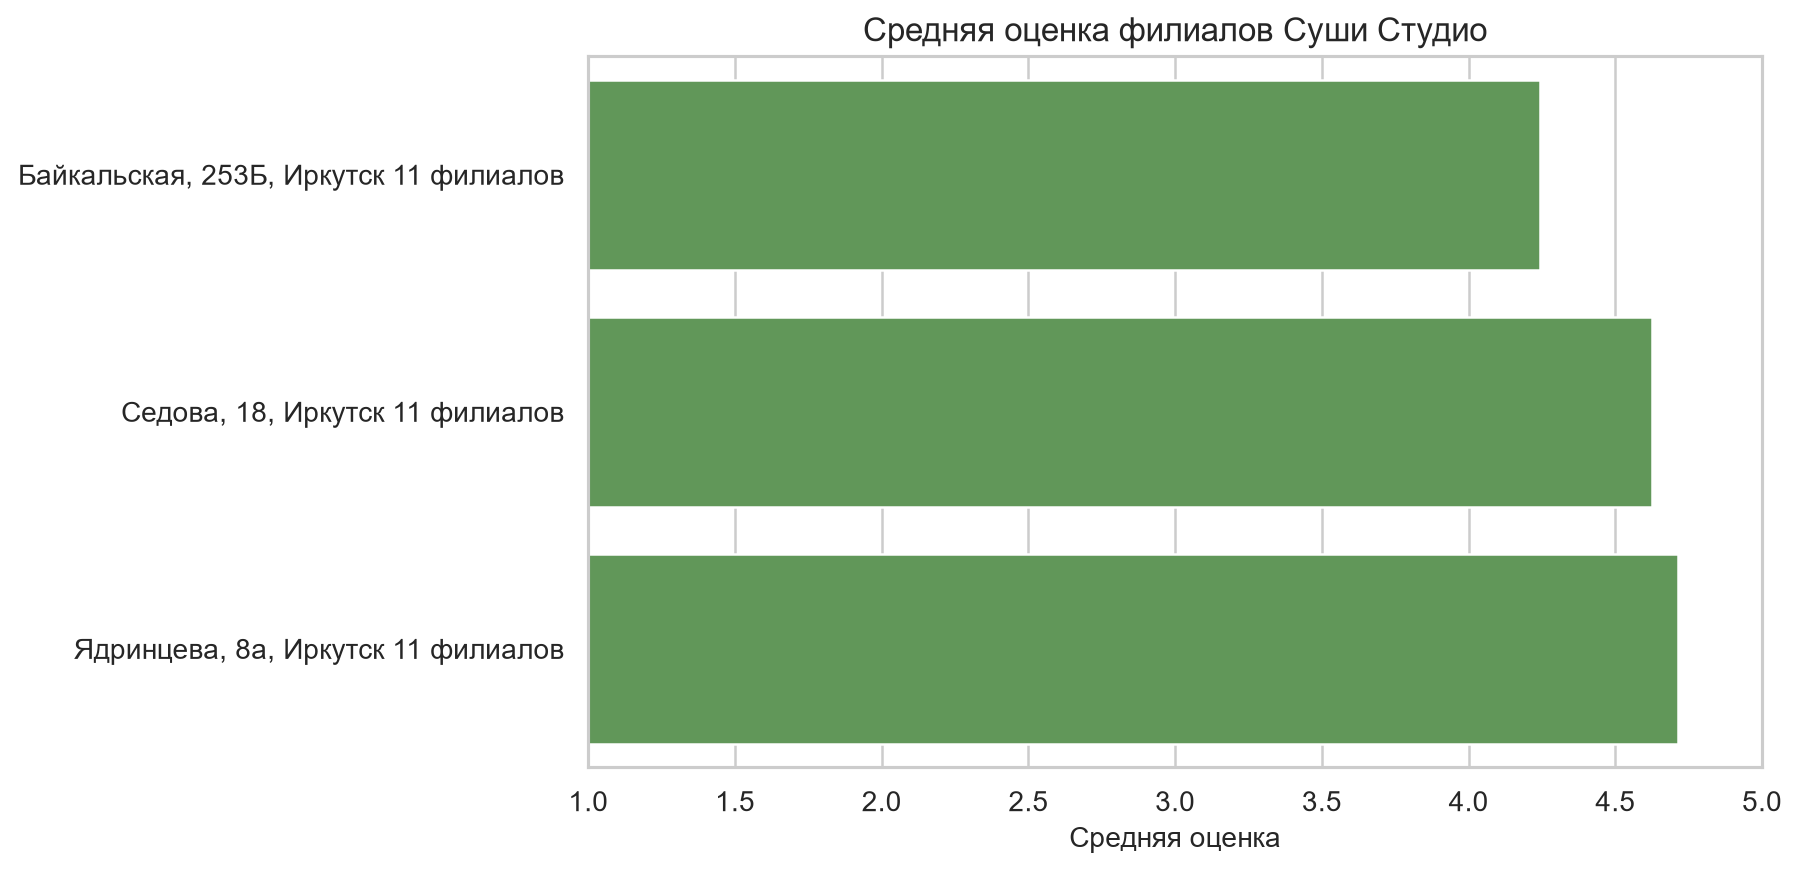

In [9]:
pipeline.create_figures(sample, company_summary, category_summary)

for filename in [
    "01_rating_distribution.png",
    "02_mean_score.png",
    "03_negative_share.png",
    "04_monthly_trend.png",
    "05_complaint_categories.png",
    "06_target_branches.png",
]:
    display(Image(filename=str(pipeline.FIGURE_DIR / filename), width=850))

## 10. Экспорт результатов

Сохраняем очищенную аналитическую выборку, плоскую таблицу для DataLens и агрегированные таблицы. UTF-8 с BOM выбран для корректного открытия русских названий в Excel и DataLens.

In [10]:
# Сохраняем очищенные строки и специальную таблицу для BI-монитора.
sample.to_csv(
    pipeline.PROCESSED_DIR / "reviews_sushi_clean.csv",
    index=False,
    encoding="utf-8-sig",
)
pipeline.export_datalens(sample)

company_summary.to_csv(
    pipeline.TABLE_DIR / "company_summary.csv", index=False, encoding="utf-8-sig"
)
category_summary.to_csv(
    pipeline.TABLE_DIR / "category_summary.csv", index=False, encoding="utf-8-sig"
)
hypotheses.to_csv(
    pipeline.TABLE_DIR / "hypothesis_results.csv", index=False, encoding="utf-8-sig"
)
top_words.to_csv(
    pipeline.TABLE_DIR / "top_negative_lemmas.csv", index=False, encoding="utf-8-sig"
)

branch_summary = (
    sample.loc[sample["Brand"].eq(pipeline.TARGET_BRAND)]
    .groupby("Adress")
    .agg(
        reviews=("review_id", "size"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
        negative_share=("is_negative", "mean"),
        positive_share=("is_positive", "mean"),
    )
    .reset_index()
    .sort_values("mean_score", ascending=False)
)
branch_summary.to_csv(
    pipeline.TABLE_DIR / "target_branch_summary.csv", index=False, encoding="utf-8-sig"
)

print("Экспорт завершён:")
print(f"- {pipeline.PROCESSED_DIR / 'datalens_reviews.csv'}")
print(f"- {pipeline.TABLE_DIR}")
print(f"- {pipeline.FIGURE_DIR}")

Экспорт завершён:
- C:\Users\Rostyan\Desktop\Практика_Ева\Eva\Проект_анализа_отзывов\data\processed\datalens_reviews.csv
- C:\Users\Rostyan\Desktop\Практика_Ева\Eva\Проект_анализа_отзывов\outputs\tables
- C:\Users\Rostyan\Desktop\Практика_Ева\Eva\Проект_анализа_отзывов\outputs\figures


## 11. Основные выводы

Следующая ячейка формирует выводы непосредственно из рассчитанных показателей. Это снижает риск расхождения текста с результатами при повторном запуске анализа.

In [11]:
target_row = company_summary.loc[company_summary["brand"].eq(pipeline.TARGET_BRAND)].iloc[0]
competitor_rows = company_summary.loc[company_summary["brand"].ne(pipeline.TARGET_BRAND)]
best = competitor_rows.sort_values("mean_score", ascending=False).iloc[0]
worst_branch = branch_summary.sort_values("mean_score").iloc[0]

service_row = hypotheses.loc[hypotheses["metric"].eq("жалоба: сервис_и_персонал")].iloc[0]

print(f"1. Средняя оценка Суши Студио: {target_row['mean_score']:.2f} из 5.")
print(f"2. Доля негативных отзывов: {target_row['negative_share']:.1%}.")
print(
    f"3. Лучший прямой конкурент по средней оценке — {best['brand']} "
    f"({best['mean_score']:.2f})."
)
print(
    f"4. В негативных отзывах тема сервиса и персонала встречается у Суши Студио "
    f"в {service_row['target_value']:.1%} случаев против "
    f"{service_row['comparison_value']:.1%} у конкурентов."
)
print(
    f"5. Наиболее проблемный адрес: {worst_branch['Adress']}; "
    f"средняя оценка {worst_branch['mean_score']:.2f}, "
    f"доля негатива {worst_branch['negative_share']:.1%}."
)
print("6. Приоритет: отдельно проработать сервис и операционные процессы проблемного филиала.")

1. Средняя оценка Суши Студио: 4.63 из 5.
2. Доля негативных отзывов: 8.1%.
3. Лучший прямой конкурент по средней оценке — Суши Точка (4.67).
4. В негативных отзывах тема сервиса и персонала встречается у Суши Студио в 47.7% случаев против 22.9% у конкурентов.
5. Наиболее проблемный адрес: Байкальская, 253Б, Иркутск 11 филиалов; средняя оценка 4.24, доля негатива 18.1%.
6. Приоритет: отдельно проработать сервис и операционные процессы проблемного филиала.


## Ограничения

1. Анализ отражает только аудиторию 2ГИС и не охватывает другие каналы обратной связи.
2. Число отзывов компаний различается; поэтому дополнительно используются доли, доверительные интервалы и непараметрические тесты.
3. Словарная категоризация допускает ошибки контекста и требует ручной проверки перед промышленным использованием.
4. Модель тональности обучена на оценках пользователей, а не на независимой ручной разметке.
5. Выводы относятся к периоду 2020–2023 годов и не описывают текущее состояние компаний.